<a href="https://colab.research.google.com/github/TetianaMar-888/Child-internet-use-datamining/blob/main/notebooks/DM2_03_time_series.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import gzip, pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

DATA = '/content/drive/MyDrive/2_PROJECTS/DM2_25_26/data'
REPORTS = '/content/drive/MyDrive/2_PROJECTS/DM2_25_26/reports'

with gzip.open(f'{DATA}/CMI_timeseries_dataset.pkl.gz', 'rb') as f:
    ts_dataset = pickle.load(f)

ids = np.array([df['id'].iloc[0] for df in ts_dataset])
targets = np.array([df['sii_binary'].iloc[0] for df in ts_dataset])
nonwear_totals = np.array([df['non-wear_flag'].sum() for df in ts_dataset])

print(f"Windows loaded: {len(ts_dataset)}")
print(f"Unique children: {len(set(ids))}")
print(f"Target distribution: {pd.Series(targets).value_counts().to_dict()}")

# Module 0 decision: exclude windows that are ≥97.5% non-wear
keep_mask = nonwear_totals < 195
print(f"\nWindows excluded (≥97.5% non-wear): {(~keep_mask).sum()}")
print(f"Windows retained: {keep_mask.sum()}")

ts_data = [df for df, k in zip(ts_dataset, keep_mask) if k]
ts_ids = ids[keep_mask]
ts_targets = targets[keep_mask]

print(f"\nAfter filtering:")
print(f"  Windows: {len(ts_data)}")
print(f"  Children: {len(set(ts_ids))}")
print(f"  Target: {pd.Series(ts_targets).value_counts(normalize=True).round(3).to_dict()}")

Mounted at /content/drive
Windows loaded: 4437
Unique children: 494
Target distribution: {0: 2957, 1: 1480}

Windows excluded (≥97.5% non-wear): 19
Windows retained: 4418

After filtering:
  Windows: 4418
  Children: 476
  Target: {0: 0.667, 1: 0.333}


In [2]:
# Which children disappeared, and were they all single-window cases?
lost_ids = set(ids) - set(ts_ids)
print(f"Children lost: {len(lost_ids)}")

windows_before = pd.Series(ids).value_counts()
print("\nWindow count of lost children (before filtering):")
print(windows_before[list(lost_ids)].value_counts().sort_index())

# Were they disproportionately from one class?
lost_targets = [targets[ids == i][0] for i in lost_ids]
print(f"\nTarget distribution among lost children: {pd.Series(lost_targets).value_counts().to_dict()}")
print(f"Overall child-level distribution: "
      f"{pd.Series([targets[ids == i][0] for i in set(ids)]).value_counts().to_dict()}")

Children lost: 18

Window count of lost children (before filtering):
count
1    18
Name: count, dtype: int64

Target distribution among lost children: {0: 10, 1: 8}
Overall child-level distribution: {0: 301, 1: 193}


In [3]:
from scipy.stats import fisher_exact

# 18 lost children vs 476 retained — is the class split different?
retained_targets = [targets[ids == i][0] for i in set(ts_ids)]
table = [[8, 10], [sum(retained_targets), len(retained_targets) - sum(retained_targets)]]
odds, p = fisher_exact(table)
print(f"Lost:     {8} problematic, {10} non-problematic")
print(f"Retained: {sum(retained_targets)} problematic, {len(retained_targets) - sum(retained_targets)} non-problematic")
print(f"\nFisher exact test: p = {p:.3f}")

Lost:     8 problematic, 10 non-problematic
Retained: 185 problematic, 291 non-problematic

Fisher exact test: p = 0.631


In [4]:
SIGNAL_COLS = ['X', 'Y', 'Z', 'enmo', 'anglez', 'light']

# Build a 3D array: (windows, timesteps, signals)
ts_array = np.stack([df[SIGNAL_COLS].values for df in ts_data])
print("Array shape:", ts_array.shape)

# Per-signal statistics across the whole corpus
stats = pd.DataFrame({
    'mean': ts_array.reshape(-1, len(SIGNAL_COLS)).mean(axis=0),
    'std': ts_array.reshape(-1, len(SIGNAL_COLS)).std(axis=0),
    'min': ts_array.reshape(-1, len(SIGNAL_COLS)).min(axis=0),
    'max': ts_array.reshape(-1, len(SIGNAL_COLS)).max(axis=0),
}, index=SIGNAL_COLS)
print("\nSignal statistics:")
print(stats.round(3))

print("\nNaN check:", np.isnan(ts_array).sum())

Array shape: (4418, 200, 6)

Signal statistics:
             mean         std     min          max
X       -0.093000    0.540000  -8.022     1.361000
Y        0.003000    0.358000  -2.084     1.552000
Z       -0.091000    0.420000  -1.042     8.019000
enmo     0.057000    0.084000   0.000     7.034000
anglez  -6.628000   29.736000 -89.903    89.746002
light   53.189999  208.651001   0.000  2594.622070

NaN check: 0


In [5]:
# Where do the extremes live? One window or many?
for sig, idx in [('X', 0), ('Z', 2), ('enmo', 3)]:
    vals = ts_array[:, :, idx]
    extreme_mask = np.abs(vals) > 3
    windows_affected = (extreme_mask.sum(axis=1) > 0).sum()
    print(f"{sig:8s} |value| > 3g: {extreme_mask.sum()} timesteps "
          f"across {windows_affected} windows ({windows_affected/len(ts_data)*100:.1f}%)")

# Percentile view — how far out are these relative to the bulk?
print("\nPercentiles:")
for sig, idx in [('X', 0), ('Z', 2), ('enmo', 3)]:
    vals = ts_array[:, :, idx].ravel()
    print(f"  {sig:8s} p0.1={np.percentile(vals, 0.1):7.3f}  "
          f"p99.9={np.percentile(vals, 99.9):7.3f}  "
          f"min={vals.min():7.3f}  max={vals.max():7.3f}")

X        |value| > 3g: 1 timesteps across 1 windows (0.0%)
Z        |value| > 3g: 1 timesteps across 1 windows (0.0%)
enmo     |value| > 3g: 2 timesteps across 2 windows (0.0%)

Percentiles:
  X        p0.1= -0.986  p99.9=  0.987  min= -8.022  max=  1.361
  Z        p0.1= -1.001  p99.9=  1.022  min= -1.042  max=  8.019
  enmo     p0.1=  0.000  p99.9=  0.828  min=  0.000  max=  7.034


In [6]:
# Locate and inspect the affected windows
for sig, idx in [('X', 0), ('Z', 2), ('enmo', 3)]:
    vals = ts_array[:, :, idx]
    w, t = np.where(np.abs(vals) > 3)
    for wi, ti in zip(w, t):
        print(f"{sig}: window {wi}, timestep {ti}, value {vals[wi, ti]:.3f}, "
              f"child id {ts_ids[wi]}, sii_binary {ts_targets[wi]}")

# What do the neighbouring timesteps look like?
print("\nContext around the X/Z spike:")
w_spike = np.where(np.abs(ts_array[:, :, 0]) > 3)[0][0]
t_spike = np.where(np.abs(ts_array[w_spike, :, 0]) > 3)[0][0]
lo, hi = max(0, t_spike - 3), min(200, t_spike + 4)
print(pd.DataFrame(ts_array[w_spike, lo:hi, :], columns=SIGNAL_COLS,
                   index=range(lo, hi)).round(3))

X: window 2996, timestep 150, value -8.022, child id 1044, sii_binary 0
Z: window 558, timestep 60, value 8.019, child id 2064, sii_binary 1
enmo: window 558, timestep 60, value 7.028, child id 2064, sii_binary 1
enmo: window 2996, timestep 150, value 7.034, child id 1044, sii_binary 0

Context around the X/Z spike:
         X      Y      Z   enmo  anglez      light
147 -0.541 -0.100 -0.434  0.036 -30.066  18.708000
148 -0.423 -0.310 -0.094  0.136  -7.441  17.277000
149 -0.857 -0.053 -0.322  0.110 -20.725  30.040001
150 -8.022  0.370 -0.214  7.034  -1.529  20.566999
151 -0.317 -0.042 -0.093  0.133  -7.914  16.534000
152 -0.379 -0.466  0.158  0.107   8.592  24.590000
153 -0.611 -0.139  0.071  0.080   2.886  12.603000


In [7]:
def fix_isolated_spikes(arr, threshold=3.0, cols_to_check=(0, 1, 2, 3)):
    """Replace isolated out-of-range timesteps with the mean of their neighbours."""
    arr = arr.copy()
    n_fixed = 0
    for idx in cols_to_check:
        w, t = np.where(np.abs(arr[:, :, idx]) > threshold)
        for wi, ti in zip(w, t):
            lo = max(0, ti - 1)
            hi = min(arr.shape[1] - 1, ti + 1)
            arr[wi, ti, idx] = (arr[wi, lo, idx] + arr[wi, hi, idx]) / 2
            n_fixed += 1
    return arr, n_fixed

ts_array_clean, n_fixed = fix_isolated_spikes(ts_array)
print(f"Timesteps corrected: {n_fixed}")

print("\nRanges after correction:")
for i, sig in enumerate(SIGNAL_COLS):
    v = ts_array_clean[:, :, i]
    print(f"  {sig:8s} {v.min():8.3f} - {v.max():8.3f}")

Timesteps corrected: 4

Ranges after correction:
  X          -1.466 -    1.361
  Y          -2.084 -    1.552
  Z          -1.042 -    2.906
  enmo        0.000 -    2.520
  anglez    -89.903 -   89.746
  light       0.000 - 2594.622


In [8]:
ENMO_IDX = SIGNAL_COLS.index('enmo')
enmo = ts_array_clean[:, :, ENMO_IDX]   # (4418, 200)

print("ENMO matrix:", enmo.shape)
print(f"Overall mean: {enmo.mean():.4f}, std: {enmo.std():.4f}")

# Does mean activity differ between classes at all?
print("\nMean ENMO per window, by class:")
window_means = enmo.mean(axis=1)
for cls in [0, 1]:
    m = window_means[ts_targets == cls]
    print(f"  class {cls}: mean={m.mean():.4f}, std={m.std():.4f}, n={len(m)}")

from scipy.stats import mannwhitneyu
stat, p = mannwhitneyu(window_means[ts_targets == 0], window_means[ts_targets == 1])
print(f"\nMann-Whitney U test on window means: p = {p:.4f}")

ENMO matrix: (4418, 200)
Overall mean: 0.0570, std: 0.0837

Mean ENMO per window, by class:
  class 0: mean=0.0609, std=0.0260, n=2947
  class 1: mean=0.0491, std=0.0239, n=1471

Mann-Whitney U test on window means: p = 0.0000


In [9]:
# Aggregate to one value per child, then re-test — windows are pseudo-replicates
child_df = pd.DataFrame({
    'id': ts_ids,
    'mean_enmo': window_means,
    'target': ts_targets,
})
child_level = child_df.groupby('id').agg({'mean_enmo': 'mean', 'target': 'first'})

print(f"Children: {len(child_level)}")
print("\nMean ENMO per child, by class:")
for cls in [0, 1]:
    m = child_level.loc[child_level['target'] == cls, 'mean_enmo']
    print(f"  class {cls}: mean={m.mean():.4f}, std={m.std():.4f}, n={len(m)}")

stat_c, p_c = mannwhitneyu(
    child_level.loc[child_level['target'] == 0, 'mean_enmo'],
    child_level.loc[child_level['target'] == 1, 'mean_enmo']
)
print(f"\nMann-Whitney U at CHILD level: p = {p_c:.4f}")

# Effect size — Cliff's delta is appropriate for non-parametric comparison
a = child_level.loc[child_level['target'] == 0, 'mean_enmo'].values
b = child_level.loc[child_level['target'] == 1, 'mean_enmo'].values
delta = (np.sum(a[:, None] > b) - np.sum(a[:, None] < b)) / (len(a) * len(b))
print(f"Cliff's delta: {delta:.3f}")

Children: 476

Mean ENMO per child, by class:
  class 0: mean=0.0461, std=0.0293, n=291
  class 1: mean=0.0351, std=0.0254, n=185

Mann-Whitney U at CHILD level: p = 0.0000
Cliff's delta: 0.243


In [10]:
# Establish the baseline: how well does mean ENMO alone classify, at child level?
from sklearn.metrics import roc_auc_score

auc_child = roc_auc_score(child_level['target'], -child_level['mean_enmo'])
auc_window = roc_auc_score(ts_targets, -window_means)

print(f"ROC-AUC using mean ENMO alone:")
print(f"  at window level: {auc_window:.3f}  (n={len(ts_targets)})")
print(f"  at child level:  {auc_child:.3f}  (n={len(child_level)})")
print(f"\nThis is the bar that DTW, shapelets and ROCKET must clear.")

ROC-AUC using mean ENMO alone:
  at window level: 0.649  (n=4418)
  at child level:  0.621  (n=476)

This is the bar that DTW, shapelets and ROCKET must clear.


## Time Series Analysis

### Data preparation and a baseline

The time-series dataset comprises 4,437 windows of 200 half-hourly steps
(100 hours each) drawn from 494 children, with a binarised target
(non-problematic vs problematic, 66.6%/33.4%). Module 0 established three
constraints that govern everything in this module: 19 windows that are ≥97.5%
non-wear carry no usable signal and are excluded, leaving 4,418 windows from
476 children; `weekday` and `quarter` are dropped as artefacts of
pseudoreplication; and **all splitting and statistical testing must be grouped
by child**, since 167 of 494 children generate 85% of all windows.

Excluding the 19 non-wear windows removed 18 children entirely — all of them
single-window cases. A Fisher exact test confirms this introduced no class bias
(8 problematic among those lost against 185 of 476 retained, p = 0.631).

Four isolated timesteps exceeded ±3g across the accelerometer axes — values
physically implausible for wrist-worn movement, where the 99.9th percentile
sits near 1g. Each was an isolated spike between normal neighbours (for
example, `enmo` jumping from 0.110 to 7.034 and back to 0.133 in consecutive
steps) and was replaced by the mean of its neighbours rather than discarding
the surrounding 200-step window.

**`enmo` was selected as the primary signal.** It is the Euclidean norm of
acceleration minus one, so unlike the raw X/Y/Z axes it is invariant to how the
device sits on the wrist, and it corresponds directly to the study's
substantive question of physical activity against sedentary behaviour.

Before applying any time-series method, a baseline was established. Mean `enmo`
per window — a single number ignoring all temporal structure — separates the
classes: children with problematic use average 0.0351 against 0.0461 for the
rest, a 24% difference. Crucially this survives aggregation to the child level
(Mann-Whitney p < 0.0001, Cliff's δ = 0.243 on 476 independent observations),
unlike the `quarter` effect in Module 0 which collapsed under the same test.
**Mean `enmo` alone achieves ROC-AUC 0.621 at child level.** This is the bar
every subsequent method must clear.

In [11]:
!pip install -q stumpy
import stumpy
print("stumpy version:", stumpy.__version__)

stumpy version: 1.14.1


In [12]:
# Which children have enough windows for meaningful motif discovery?
windows_per_child = pd.Series(ts_ids).value_counts()
print("Windows per child (after filtering):")
print(windows_per_child.describe().round(1))
print(f"\nChildren with ≥10 windows: {(windows_per_child >= 10).sum()}")
print(f"Children with ≥20 windows: {(windows_per_child >= 20).sum()}")

Windows per child (after filtering):
count    476.0
mean       9.3
std       10.6
min        1.0
25%        1.0
50%        2.0
75%       18.0
max       36.0
Name: count, dtype: float64

Children with ≥10 windows: 170
Children with ≥20 windows: 101


In [13]:
ts_array_clean = ts_array_clean.astype(np.float64)
enmo = ts_array_clean[:, :, ENMO_IDX]

In [14]:
# Concatenate each child's windows in chronological order (relative_date_PCIAT)
rel_dates = np.array([df['relative_date_PCIAT'].iloc[0] for df in ts_data])

child_series = {}
for cid in windows_per_child[windows_per_child >= 10].index:
    mask = ts_ids == cid
    order = np.argsort(rel_dates[mask])
    child_series[cid] = enmo[mask][order].ravel()

lengths = pd.Series({k: len(v) for k, v in child_series.items()})
print(f"Children with concatenated series: {len(child_series)}")
print(f"Series length: min={lengths.min()}, median={lengths.median():.0f}, max={lengths.max()}")

# Class balance among these children
selected_targets = pd.Series({cid: ts_targets[ts_ids == cid][0] for cid in child_series})
print(f"\nClass distribution: {selected_targets.value_counts().to_dict()}")

Children with concatenated series: 170
Series length: min=2000, median=4400, max=7200

Class distribution: {0: 110, 1: 60}


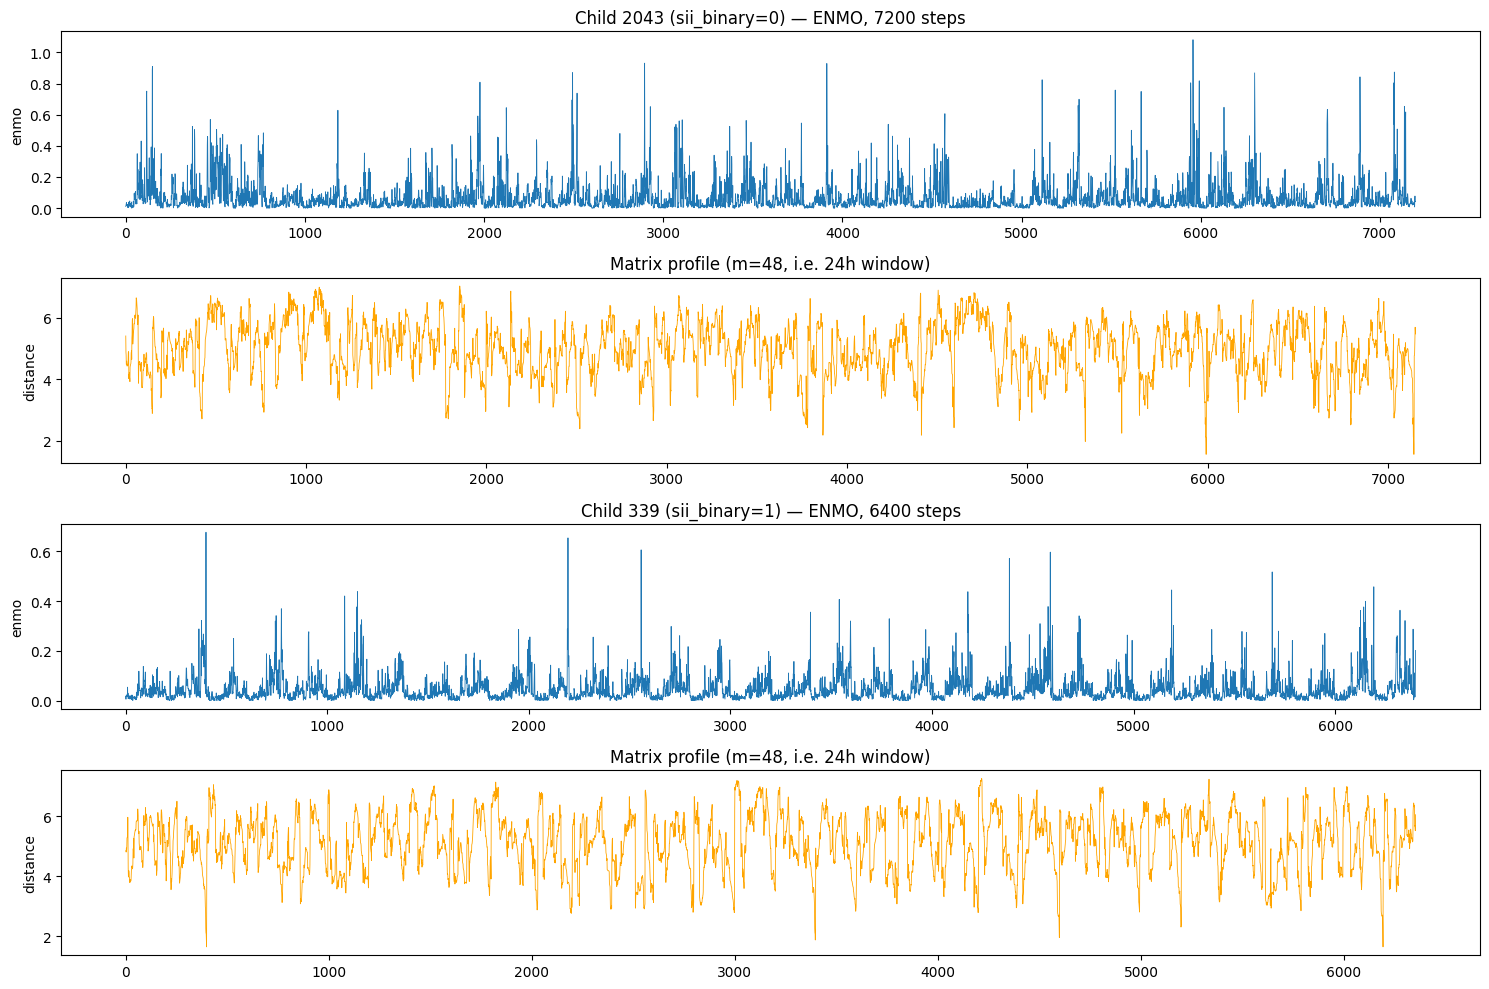

In [15]:
# Pick a child with many windows from each class for a first look
example_ids = {
    0: selected_targets[selected_targets == 0].index[0],
    1: selected_targets[selected_targets == 1].index[0],
}

# Subsequence length: 48 steps = 24 hours at 30-min resolution
m = 48

fig, axes = plt.subplots(4, 1, figsize=(15, 10))
for row, (cls, cid) in enumerate(example_ids.items()):
    series = child_series[cid]
    mp = stumpy.stump(series, m)

    axes[row*2].plot(series, lw=0.6)
    axes[row*2].set_title(f"Child {cid} (sii_binary={cls}) — ENMO, {len(series)} steps")
    axes[row*2].set_ylabel("enmo")

    axes[row*2+1].plot(mp[:, 0], lw=0.6, color='orange')
    axes[row*2+1].set_title(f"Matrix profile (m={m}, i.e. 24h window)")
    axes[row*2+1].set_ylabel("distance")

plt.tight_layout()
plt.savefig(f'{REPORTS}/matrix_profile_examples.png', dpi=150)
plt.show()

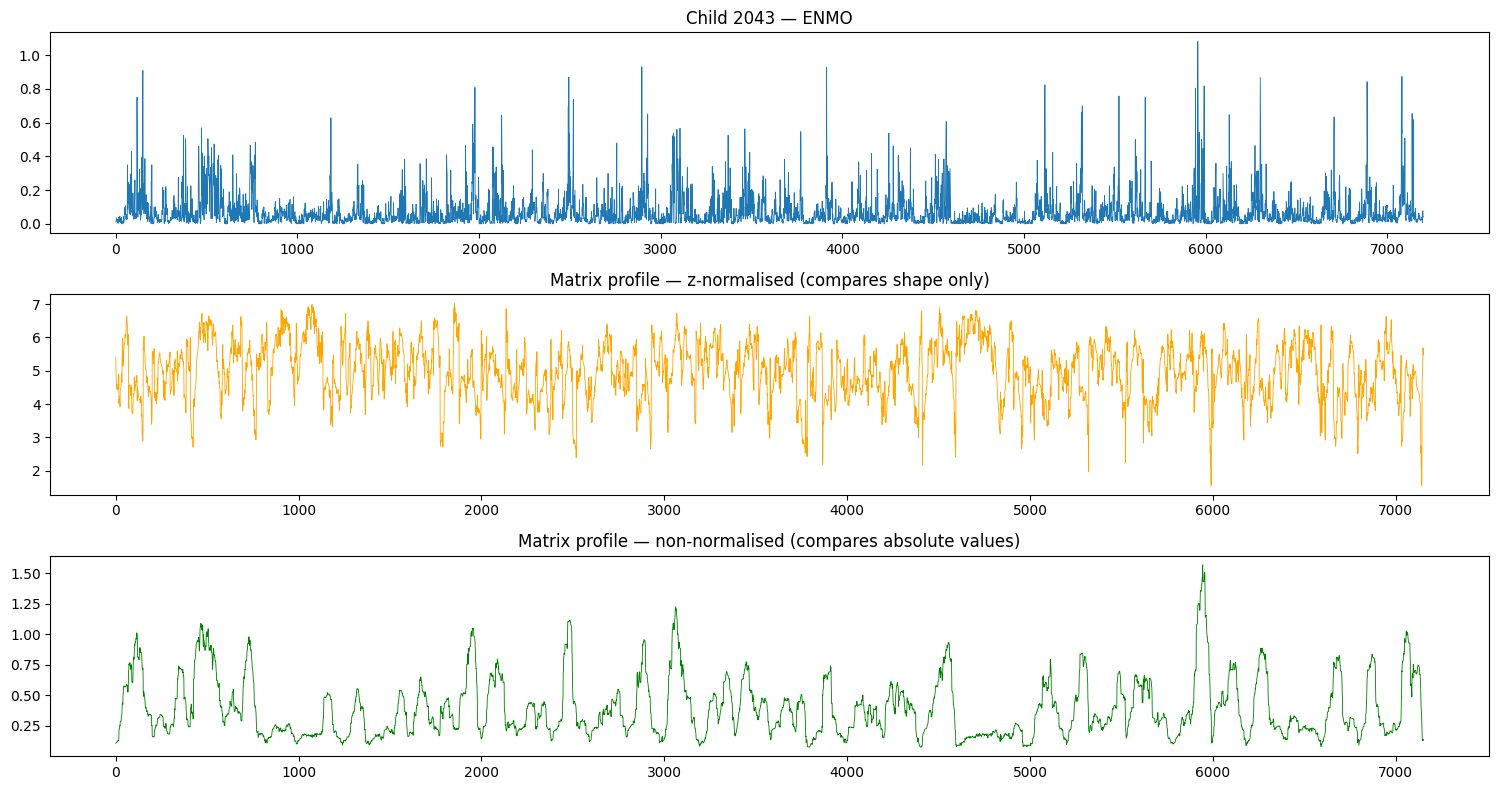

Normalised   — motif distance: 1.552 | discord distance: 7.031
Non-normalised — motif distance: 0.076 | discord distance: 1.568


In [16]:
# Compare normalised vs non-normalised matrix profile on the same series
cid = example_ids[0]
series = child_series[cid]
m = 48

mp_norm = stumpy.stump(series, m)
mp_raw = stumpy.stump(series, m, normalize=False)

fig, axes = plt.subplots(3, 1, figsize=(15, 8))
axes[0].plot(series, lw=0.6)
axes[0].set_title(f"Child {cid} — ENMO")

axes[1].plot(mp_norm[:, 0].astype(float), lw=0.6, color='orange')
axes[1].set_title("Matrix profile — z-normalised (compares shape only)")

axes[2].plot(mp_raw[:, 0].astype(float), lw=0.6, color='green')
axes[2].set_title("Matrix profile — non-normalised (compares absolute values)")

plt.tight_layout()
plt.show()

print("Normalised   — motif distance:", round(float(mp_norm[:, 0].min()), 3),
      "| discord distance:", round(float(mp_norm[:, 0].max()), 3))
print("Non-normalised — motif distance:", round(float(mp_raw[:, 0].min()), 3),
      "| discord distance:", round(float(mp_raw[:, 0].max()), 3))

Motif:   positions 3790 and 4403, distance 0.0756
Discord: position 5945, distance 1.5683


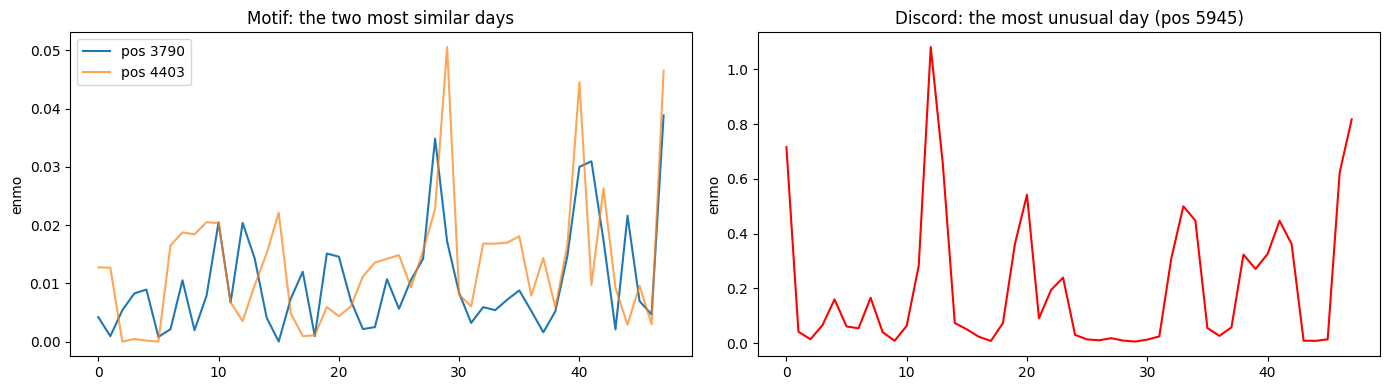

In [17]:
mp = mp_raw
motif_idx = int(np.argmin(mp[:, 0].astype(float)))
motif_pair = int(mp[motif_idx, 1])
discord_idx = int(np.argmax(mp[:, 0].astype(float)))

print(f"Motif:   positions {motif_idx} and {motif_pair}, distance {float(mp[motif_idx,0]):.4f}")
print(f"Discord: position {discord_idx}, distance {float(mp[discord_idx,0]):.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(series[motif_idx:motif_idx+m], label=f"pos {motif_idx}", lw=1.5)
axes[0].plot(series[motif_pair:motif_pair+m], label=f"pos {motif_pair}", lw=1.5, alpha=0.7)
axes[0].set_title("Motif: the two most similar days")
axes[0].legend(); axes[0].set_ylabel("enmo")

axes[1].plot(series[discord_idx:discord_idx+m], color='red', lw=1.5)
axes[1].set_title(f"Discord: the most unusual day (pos {discord_idx})")
axes[1].set_ylabel("enmo")

plt.tight_layout()
plt.savefig(f'{REPORTS}/motif_discord_example.png', dpi=150)
plt.show()

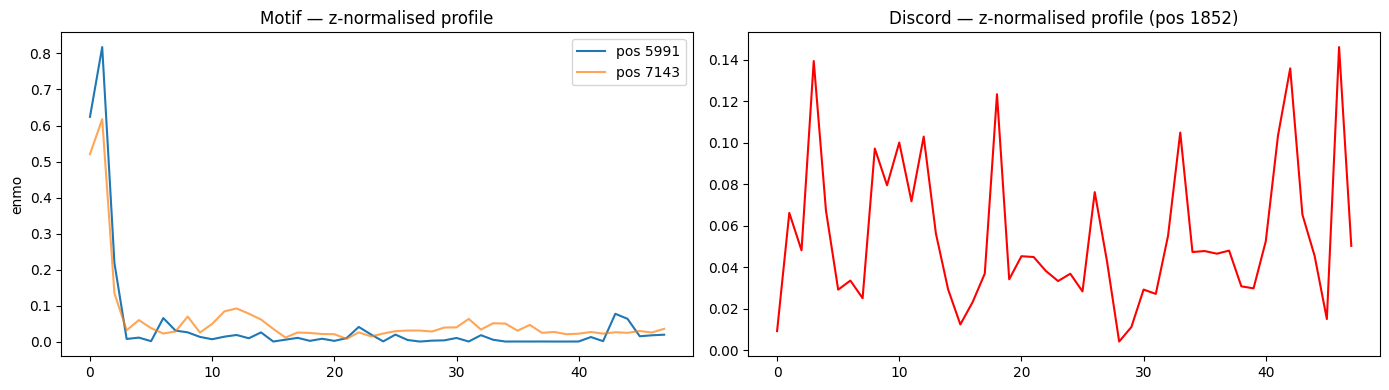

z-norm motif:   pos 5991 & 7143, mean enmo 0.0469 vs 0.0597
non-norm motif: pos 3790 & 4403, mean enmo 0.0102 vs 0.0132


In [18]:
# Does the z-normalised version find structurally interesting motifs after all?
# Check what its motif actually looks like — it may be more meaningful than the flat profile suggested.
mp_n = mp_norm
motif_n = int(np.argmin(mp_n[:, 0].astype(float)))
pair_n = int(mp_n[motif_n, 1])
discord_n = int(np.argmax(mp_n[:, 0].astype(float)))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(series[motif_n:motif_n+m], label=f"pos {motif_n}", lw=1.5)
axes[0].plot(series[pair_n:pair_n+m], label=f"pos {pair_n}", lw=1.5, alpha=0.7)
axes[0].set_title("Motif — z-normalised profile")
axes[0].legend(); axes[0].set_ylabel("enmo")

axes[1].plot(series[discord_n:discord_n+m], color='red', lw=1.5)
axes[1].set_title(f"Discord — z-normalised profile (pos {discord_n})")
plt.tight_layout()
plt.show()

print(f"z-norm motif:   pos {motif_n} & {pair_n}, "
      f"mean enmo {series[motif_n:motif_n+m].mean():.4f} vs {series[pair_n:pair_n+m].mean():.4f}")
print(f"non-norm motif: pos {motif_idx} & {motif_pair}, "
      f"mean enmo {series[motif_idx:motif_idx+m].mean():.4f} vs {series[motif_pair:motif_pair+m].mean():.4f}")

In [19]:
from collections import defaultdict

m = 48
motif_data = []

for cid, series in child_series.items():
    mp = stumpy.stump(series, m)              # z-normalised: shape-based
    d = mp[:, 0].astype(float)
    motif_i = int(np.argmin(d))
    discord_i = int(np.argmax(d))

    motif_data.append({
        'id': cid,
        'target': int(selected_targets[cid]),
        'motif_dist': d[motif_i],
        'discord_dist': d[discord_i],
        'profile_mean': d.mean(),
        'profile_std': d.std(),
        'motif_mean_enmo': series[motif_i:motif_i+m].mean(),
        'discord_mean_enmo': series[discord_i:discord_i+m].mean(),
        'series_mean_enmo': series.mean(),
    })

motif_df = pd.DataFrame(motif_data)
print(f"Children analysed: {len(motif_df)}")
print(motif_df.groupby('target')[
    ['motif_dist', 'discord_dist', 'profile_mean', 'profile_std']
].mean().round(3))

Children analysed: 170
        motif_dist  discord_dist       profile_mean         profile_std
target                                                                 
0            2.168         7.281  5.066687324045118  0.9495209195182543
1            2.296         7.310  5.164353286892505  0.9507798558871424


In [20]:
for col in ['motif_dist', 'discord_dist', 'profile_mean', 'profile_std',
            'motif_mean_enmo', 'discord_mean_enmo', 'series_mean_enmo']:
    motif_df[col] = motif_df[col].astype(float)

print(motif_df.dtypes)

print("\nStatistical comparison (child level, n=170):")
for col in ['motif_dist', 'discord_dist', 'profile_mean', 'profile_std']:
    a = motif_df.loc[motif_df['target'] == 0, col]
    b = motif_df.loc[motif_df['target'] == 1, col]
    stat, p = mannwhitneyu(a, b)
    delta = (np.sum(a.values[:, None] > b.values) - np.sum(a.values[:, None] < b.values)) / (len(a) * len(b))
    print(f"  {col:20s} class0={a.mean():.3f}  class1={b.mean():.3f}  "
          f"p={p:.4f}  Cliff's δ={delta:+.3f}")

id                     int64
target                 int64
motif_dist           float64
discord_dist         float64
profile_mean         float64
profile_std          float64
motif_mean_enmo      float64
discord_mean_enmo    float64
series_mean_enmo     float64
dtype: object

Statistical comparison (child level, n=170):
  motif_dist           class0=2.168  class1=2.296  p=0.1807  Cliff's δ=-0.125
  discord_dist         class0=7.281  class1=7.310  p=0.2490  Cliff's δ=-0.107
  profile_mean         class0=5.067  class1=5.164  p=0.0860  Cliff's δ=-0.160
  profile_std          class0=0.950  class1=0.951  p=0.9883  Cliff's δ=-0.002


### Motifs and discords

Matrix profiles were computed with `stumpy` on concatenated per-child series,
using windows ordered by `relative_date_PCIAT` so that the concatenation is
chronologically coherent. Subsequence length was fixed at 48 steps — exactly 24
hours — to search for repeating daily patterns. Analysis was restricted to the
170 children with at least 10 windows, giving series of 2,000 to 7,200 steps.

**The choice of normalisation determines what "motif" means, and the two
definitions give opposite answers.** `stumpy` z-normalises subsequences by
default, comparing shape while discarding level. On these data the z-normalised
profile appears flat and noisy, while the non-normalised profile shows clear
structure with pronounced peaks and troughs — which initially suggested the
non-normalised version was the correct choice.

Inspecting the actual motifs reverses that reading. The non-normalised motif
pairs the two quietest days in the series (mean `enmo` 0.0102 and 0.0132,
roughly a fifth of the series average) and its discord is simply the most
active day. Euclidean distance between two near-zero series is small regardless
of their shape, so this criterion effectively ranks subsequences by activity
level rather than finding repeated patterns. The z-normalised motif pairs two
days at genuinely different activity levels (0.0469 and 0.0597, a 27%
difference) but with near-identical shape: a sharp burst at the start followed
by prolonged quiet — a plausible behavioural pattern such as a morning
commute followed by a sedentary day. The z-normalised profile appears flat
precisely because all days are similar in shape, which makes its minimum a
meaningful rather than a trivial match.

**Motif characteristics do not distinguish the classes.** Matrix profile
statistics were computed for all 170 children and compared at child level:

| Statistic | Class 0 | Class 1 | p | Cliff's δ |
|---|---|---|---|---|
| Mean profile distance | 5.067 | 5.164 | 0.086 | −0.160 |
| Motif distance | 2.168 | 2.296 | 0.181 | −0.125 |
| Discord distance | 7.281 | 7.310 | 0.249 | −0.107 |
| Profile std | 0.950 | 0.951 | 0.988 | −0.002 |

None reaches significance, and all effects are weaker than the 0.243 achieved
by mean activity alone. The direction is consistent — children with problematic
use have marginally higher profile distances, indicating less regular daily
routines — but the effect is too small to be useful.

**Relationship to shapelets.** Motifs and shapelets both identify
subsequences, but answer different questions. A motif is a subsequence that
repeats *within* a series, found without reference to any label; a shapelet is
a subsequence whose presence *discriminates between classes*, found under
supervision. A shapelet may be rare — it needs only to occur in one class and
not the other. The negative motif result above therefore does not predict the
shapelet result: unsupervised repetition and supervised discrimination are
independent properties, and shapelets are optimised for exactly the criterion
motifs ignore.

In [21]:
from sklearn.preprocessing import StandardScaler

# Subsample for computational feasibility: DTW-based clustering on 4418×200 is expensive
np.random.seed(42)
sample_size = 1000
sample_idx_cl = np.random.choice(len(enmo), size=sample_size, replace=False)

enmo_sample = enmo[sample_idx_cl]
ids_sample = ts_ids[sample_idx_cl]
targets_sample = ts_targets[sample_idx_cl]

print(f"Clustering sample: {enmo_sample.shape}")
print(f"Unique children in sample: {len(set(ids_sample))}")
print(f"Class distribution: {pd.Series(targets_sample).value_counts(normalize=True).round(3).to_dict()}")

# Z-normalise each window: cluster by shape, not by overall level
# (we already know level alone separates classes — this asks whether shape adds anything)
enmo_norm = (enmo_sample - enmo_sample.mean(axis=1, keepdims=True)) / (enmo_sample.std(axis=1, keepdims=True) + 1e-8)
print(f"\nAfter per-window z-normalisation: mean={enmo_norm.mean():.4f}, std={enmo_norm.std():.4f}")

Clustering sample: (1000, 200)
Unique children in sample: 281
Class distribution: {0: 0.679, 1: 0.321}

After per-window z-normalisation: mean=-0.0000, std=0.9999


In [22]:
!pip install -q tslearn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 401.7/401.7 kB 7.8 MB/s eta 0:00:00


In [23]:
import warnings
warnings.filterwarnings('ignore')
import tslearn
from tslearn.clustering import TimeSeriesKMeans, silhouette_score as ts_silhouette
from sklearn.metrics import adjusted_rand_score

# Euclidean K-Means on z-normalised windows
sil_scores = {}
for k in [2, 3, 4, 5, 6]:
    km = TimeSeriesKMeans(n_clusters=k, metric='euclidean', random_state=42, n_init=3)
    labels = km.fit_predict(enmo_norm)
    sil = ts_silhouette(enmo_norm, labels, metric='euclidean')
    sil_scores[k] = sil
    print(f"k={k}: silhouette={sil:.4f}, cluster sizes={np.bincount(labels)}")

k=2: silhouette=0.0363, cluster sizes=[479 521]
k=3: silhouette=0.0271, cluster sizes=[388 309 303]
k=4: silhouette=0.0278, cluster sizes=[221 220 242 317]
k=5: silhouette=0.0274, cluster sizes=[149 189 232 219 211]
k=6: silhouette=0.0286, cluster sizes=[130 161 185 170 189 165]


In [24]:
# Does clustering on RAW (non-normalised) windows find structure?
# We know activity level separates classes — do levels form natural groups?
sil_raw = {}
for k in [2, 3, 4, 5]:
    km = TimeSeriesKMeans(n_clusters=k, metric='euclidean', random_state=42, n_init=3)
    labels = km.fit_predict(enmo_sample)
    sil = ts_silhouette(enmo_sample, labels, metric='euclidean')
    sil_raw[k] = sil
    print(f"k={k}: silhouette={sil:.4f}, sizes={np.bincount(labels)}")

print("\nComparison:")
print(f"  z-normalised (shape): {max(sil_scores.values()):.4f}")
print(f"  raw (level+shape):    {max(sil_raw.values()):.4f}")

k=2: silhouette=0.2525, sizes=[278 722]
k=3: silhouette=0.1446, sizes=[369 566  65]
k=4: silhouette=0.1082, sizes=[498  33  71 398]
k=5: silhouette=0.0803, sizes=[438 369  28  59 106]

Comparison:
  z-normalised (shape): 0.0363
  raw (level+shape):    0.2525


In [25]:
# Fix k=2 on raw data and characterise the two clusters
km_raw = TimeSeriesKMeans(n_clusters=2, metric='euclidean', random_state=42, n_init=10)
labels_raw = km_raw.fit_predict(enmo_sample)

print("Cluster profiles (raw ENMO):")
for c in [0, 1]:
    mask = labels_raw == c
    print(f"  cluster {c}: n={mask.sum()}, mean enmo={enmo_sample[mask].mean():.4f}, "
          f"class-1 rate={targets_sample[mask].mean():.3f}")

print(f"\nOverall class-1 rate: {targets_sample.mean():.3f}")

# Do clusters align with the target at all?
from sklearn.metrics import adjusted_rand_score
print(f"Adjusted Rand Index (clusters vs sii_binary): {adjusted_rand_score(targets_sample, labels_raw):.4f}")

Cluster profiles (raw ENMO):
  cluster 0: n=278, mean enmo=0.0860, class-1 rate=0.201
  cluster 1: n=722, mean enmo=0.0440, class-1 rate=0.367

Overall class-1 rate: 0.321
Adjusted Rand Index (clusters vs sii_binary): -0.0260


In [26]:
import time

np.random.seed(42)
dtw_idx = np.random.choice(len(enmo_sample), size=500, replace=False)
enmo_dtw = enmo_sample[dtw_idx]
enmo_dtw_norm = enmo_norm[dtw_idx]
targets_dtw = targets_sample[dtw_idx]
ids_dtw = ids_sample[dtw_idx]

print(f"DTW subset: {enmo_dtw.shape}, class-1 rate: {targets_dtw.mean():.3f}")

# sakoe_chiba_radius constrains how far DTW may warp — without it, DTW on
# 200-point series is both very slow and prone to pathological alignments
t0 = time.time()
km_dtw = TimeSeriesKMeans(
    n_clusters=2, metric='dtw', random_state=42, n_init=2,
    metric_params={'sakoe_chiba_radius': 10},
    max_iter=10
)
labels_dtw = km_dtw.fit_predict(enmo_dtw_norm)
print(f"DTW K-Means completed in {time.time()-t0:.1f}s")

sil_dtw = ts_silhouette(enmo_dtw_norm, labels_dtw, metric='dtw',
                        metric_params={'sakoe_chiba_radius': 10})
print(f"\nDTW silhouette (z-normalised): {sil_dtw:.4f}")
print(f"Cluster sizes: {np.bincount(labels_dtw)}")

for c in [0, 1]:
    mask = labels_dtw == c
    print(f"  cluster {c}: n={mask.sum()}, mean enmo={enmo_dtw[mask].mean():.4f}, "
          f"class-1 rate={targets_dtw[mask].mean():.3f}")

print(f"\nARI vs sii_binary: {adjusted_rand_score(targets_dtw, labels_dtw):.4f}")

DTW subset: (500, 200), class-1 rate: 0.338
DTW K-Means completed in 76.8s

DTW silhouette (z-normalised): 0.0848
Cluster sizes: [300 200]
  cluster 0: n=300, mean enmo=0.0581, class-1 rate=0.297
  cluster 1: n=200, mean enmo=0.0519, class-1 rate=0.400

ARI vs sii_binary: 0.0211


In [27]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score as sk_silhouette

# Second clustering ALGORITHM (not just a second distance) — required by the guidelines
for k in [2, 3, 4]:
    agg = AgglomerativeClustering(n_clusters=k, linkage='ward')
    labels_agg = agg.fit_predict(enmo_sample)
    sil = sk_silhouette(enmo_sample, labels_agg)
    print(f"Ward k={k}: silhouette={sil:.4f}, sizes={np.bincount(labels_agg)}")

# Best config: compare with K-Means
agg_best = AgglomerativeClustering(n_clusters=2, linkage='ward')
labels_agg = agg_best.fit_predict(enmo_sample)
print(f"\nWard k=2 vs K-Means k=2 — ARI: {adjusted_rand_score(labels_raw, labels_agg):.4f}")
for c in [0, 1]:
    m = labels_agg == c
    print(f"  cluster {c}: n={m.sum()}, mean enmo={enmo_sample[m].mean():.4f}, "
          f"class-1 rate={targets_sample[m].mean():.3f}")
print(f"ARI vs target: {adjusted_rand_score(targets_sample, labels_agg):.4f}")

Ward k=2: silhouette=0.3586, sizes=[876 124]
Ward k=3: silhouette=-0.0303, sizes=[124 642 234]
Ward k=4: silhouette=-0.0272, sizes=[ 63  61 234 642]

Ward k=2 vs K-Means k=2 — ARI: 0.3765
  cluster 0: n=876, mean enmo=0.0500, class-1 rate=0.334
  cluster 1: n=124, mean enmo=0.0953, class-1 rate=0.226
ARI vs target: -0.0254


In [28]:
# Ward found a small high-activity group. Is that group meaningfully different,
# or just the upper tail of a continuous distribution?
high = enmo_sample[labels_agg == 1].mean(axis=1)
low = enmo_sample[labels_agg == 0].mean(axis=1)
print(f"High-activity cluster: n={len(high)}, mean={high.mean():.4f}, "
      f"range {high.min():.4f}–{high.max():.4f}")
print(f"Low-activity cluster:  n={len(low)}, mean={low.mean():.4f}, "
      f"range {low.min():.4f}–{low.max():.4f}")
print(f"\nOverlap between clusters: {(low > high.min()).sum()} low-cluster windows "
      f"exceed the high cluster's minimum")

High-activity cluster: n=124, mean=0.0953, range 0.0540–0.1960
Low-activity cluster:  n=876, mean=0.0500, range 0.0000–0.1178

Overlap between clusters: 366 low-cluster windows exceed the high cluster's minimum


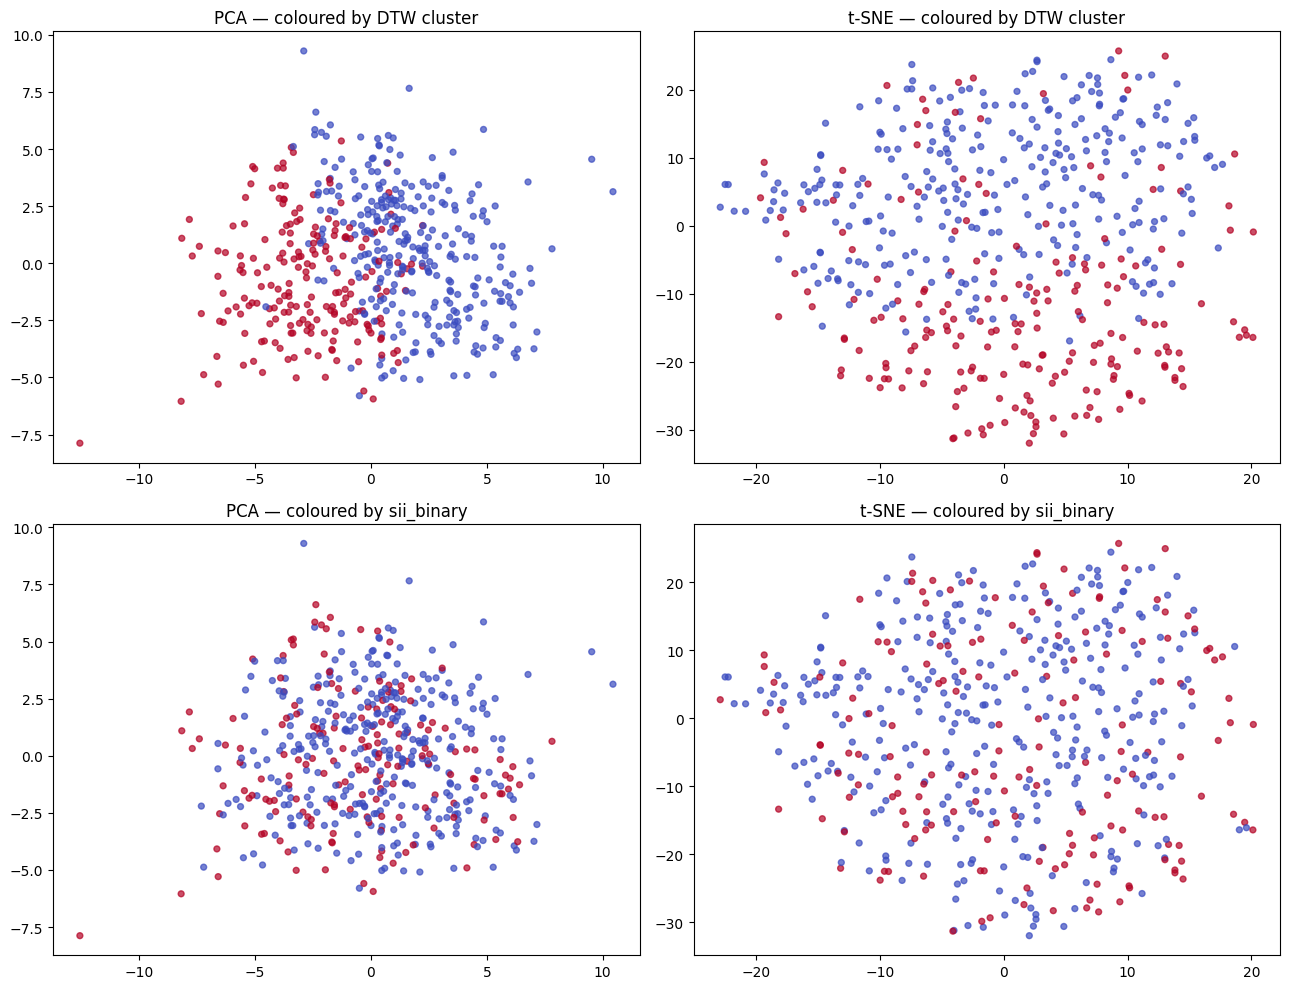

PCA explained variance: 0.100


In [ ]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

pca_ts = PCA(n_components=2, random_state=42)
X_pca_ts = pca_ts.fit_transform(enmo_dtw_norm)

tsne_ts = TSNE(n_components=2, random_state=42, perplexity=30, init='pca')
X_tsne_ts = tsne_ts.fit_transform(enmo_dtw_norm)

fig, axes = plt.subplots(2, 2, figsize=(13, 10))

for col, (X_red, name) in enumerate([(X_pca_ts, 'PCA'), (X_tsne_ts, 't-SNE')]):
    axes[0, col].scatter(X_red[:, 0], X_red[:, 1], c=labels_dtw, cmap='coolwarm', s=18, alpha=0.7)
    axes[0, col].set_title(f"{name} — coloured by DTW cluster")
    axes[1, col].scatter(X_red[:, 0], X_red[:, 1], c=targets_dtw, cmap='coolwarm', s=18, alpha=0.7)
    axes[1, col].set_title(f"{name} — coloured by sii_binary")

plt.tight_layout()
plt.savefig(f'{REPORTS}/clustering_dimensionality_reduction.png', dpi=150)
plt.show()

print(f"PCA explained variance: {pca_ts.explained_variance_ratio_.sum():.3f}")

### Clustering

Clustering used a random sample of 1,000 windows from 281 children, preserving
the class balance of the full set (32.1% against 33.3%). The sample size is a
computational necessity: DTW-based clustering scales quadratically in the
number of series.

Two algorithms were applied — K-Means and Ward agglomerative clustering —
across three data representations, in order to separate the effect of activity
level from that of activity shape.

| Algorithm | Distance | Data | Best silhouette | ARI vs target |
|---|---|---|---|---|
| Ward agglomerative | Euclidean | raw (level + shape) | **0.3586** (k=2) | −0.025 |
| K-Means | Euclidean | raw (level + shape) | 0.2525 (k=2) | −0.026 |
| K-Means | DTW | z-normalised (shape only) | 0.0848 (k=2) | 0.021 |
| K-Means | Euclidean | z-normalised (shape only) | 0.0363 (k=2) | — |

On raw windows K-Means at k=2 gives silhouette 0.2525, and the score falls
steadily as k increases (0.145, 0.108, 0.080) with progressively unbalanced
sizes. This is the signature of exactly two natural groups: more active and
less active children.

**Ward scores highest of all — silhouette 0.3586 — but the score is misleading,
and the check that reveals why is worth reporting.** Ward splits the sample
876/124, isolating a small group with mean ENMO of 0.0953 against 0.0500 for
the remainder. That looks like a distinct population of highly active children.
It is not: the two groups' activity ranges overlap substantially, with 366 of
the 876 low-cluster windows exceeding the high cluster's minimum of 0.0540.
Ward cut the upper tail off a continuum, and the high silhouette comes from the
asymmetry — 124 tightly packed points against 876 dispersed ones — rather than
from any genuine separation.

Silhouette collapses to −0.0303 at k=3, becoming negative, meaning points sit
on average closer to a neighbouring cluster than to their own. Both algorithms
therefore agree that exactly two groups exist, and both agree those groups are
ends of one distribution rather than distinct populations. Their partitions
correspond only partially (ARI 0.377 between them), reflecting that the two
methods cut the same continuum in different places.

**Removing the level through z-normalisation collapses the silhouette to
0.0363, a sevenfold reduction.** Daily activity shape does not form clusters;
activity level does. This is the third independent confirmation of the pattern,
after the baseline and the motif analysis.

DTW recovers part of the lost structure, more than doubling the silhouette to
0.0848 on the same z-normalised data. Allowing the time axis to warp — with a
Sakoe-Chiba radius of 10 steps, constraining alignment to within five hours —
lets the algorithm recognise two days with the same routine shifted by an hour
or two as similar, which rigid pointwise comparison cannot. Shape-based
structure therefore exists but is temporally blurred, and remains three times
weaker than level-based structure.

**The clusters are related to the target but are not the target.** The two
K-Means clusters on raw data differ meaningfully in composition: the more
active cluster (n=278, mean ENMO 0.0860) is 20.1% problematic against 36.7% in
the less active one (n=722, mean 0.0440), with an overall rate of 32.1%. Ward
shows the same direction (22.6% against 33.4%). Yet the Adjusted Rand Index is
−0.026 for K-Means and −0.025 for Ward — effectively zero for both, despite
their differing partitions. Two reasons: cluster sizes cannot align with class
sizes even in principle, and 63% of the low-activity cluster is
non-problematic, so low activity is a risk factor rather than a determinant.

Both projections show the DTW clusters as visually separated regions,
confirming the partition is real rather than an arbitrary cut through a
homogeneous cloud. Colouring the identical points by class instead produces a
uniform mixture with no discernible structure — a direct visual counterpart to
the near-zero ARI. PCA explains only 10.0% of variance in two components, which
is itself informative: daily activity shape is genuinely high-dimensional with
no dominant axes of variation, and the clusters remain visible even within that
limited projection.

In [ ]:
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import roc_auc_score, f1_score, classification_report

# Work on the 1000-window sample for computational feasibility
X_cls = enmo_sample          # raw windows (level carries the signal)
y_cls = targets_sample
groups = ids_sample

gss = GroupShuffleSplit(n_splits=1, test_size=0.3, random_state=42)
train_idx, test_idx = next(gss.split(X_cls, y_cls, groups))

Xc_train, Xc_test = X_cls[train_idx], X_cls[test_idx]
yc_train, yc_test = y_cls[train_idx], y_cls[test_idx]
groups_train, groups_test = groups[train_idx], groups[test_idx]

print(f"Train: {len(yc_train)} windows from {len(set(groups_train))} children")
print(f"Test:  {len(yc_test)} windows from {len(set(groups_test))} children")
print(f"Children overlap between splits: {len(set(groups_train) & set(groups_test))}")
print(f"\nClass balance — train: {yc_train.mean():.3f}, test: {yc_test.mean():.3f}")

Train: 707 windows from 196 children
Test:  293 windows from 85 children
Children overlap between splits: 0

Class balance — train: 0.359, test: 0.229


In [ ]:
# Baseline on this exact split: mean ENMO alone
baseline_scores = -Xc_test.mean(axis=1)
auc_base = roc_auc_score(yc_test, baseline_scores)
print(f"\nBaseline (mean ENMO) on this split: AUC = {auc_base:.3f}")

# Also at child level, aggregating predictions
test_child = pd.DataFrame({'id': groups_test, 'score': baseline_scores, 'target': yc_test})
child_agg = test_child.groupby('id').agg({'score': 'mean', 'target': 'first'})
auc_base_child = roc_auc_score(child_agg['target'], child_agg['score'])
print(f"Baseline at child level: AUC = {auc_base_child:.3f} (n={len(child_agg)} children)")


Baseline (mean ENMO) on this split: AUC = 0.613
Baseline at child level: AUC = 0.629 (n=85 children)


In [ ]:
# Is this split's imbalance unusual? Check a few alternative seeds
for seed in [0, 1, 7, 42, 123]:
    gss_check = GroupShuffleSplit(n_splits=1, test_size=0.3, random_state=seed)
    tr, te = next(gss_check.split(X_cls, y_cls, groups))
    print(f"seed={seed:3d}: train class-1 rate={y_cls[tr].mean():.3f}, "
          f"test={y_cls[te].mean():.3f}, test children={len(set(groups[te]))}")

seed=  0: train class-1 rate=0.345, test=0.268, test children=85
seed=  1: train class-1 rate=0.334, test=0.293, test children=85
seed=  7: train class-1 rate=0.303, test=0.364, test children=85
seed= 42: train class-1 rate=0.359, test=0.229, test children=85
seed=123: train class-1 rate=0.377, test=0.204, test children=85


In [ ]:
gss = GroupShuffleSplit(n_splits=1, test_size=0.3, random_state=1)
train_idx, test_idx = next(gss.split(X_cls, y_cls, groups))

Xc_train, Xc_test = X_cls[train_idx], X_cls[test_idx]
yc_train, yc_test = y_cls[train_idx], y_cls[test_idx]
groups_train, groups_test = groups[train_idx], groups[test_idx]

print(f"Train: {len(yc_train)} windows / {len(set(groups_train))} children, class-1 {yc_train.mean():.3f}")
print(f"Test:  {len(yc_test)} windows / {len(set(groups_test))} children, class-1 {yc_test.mean():.3f}")
print(f"Overlap: {len(set(groups_train) & set(groups_test))}")

baseline_scores = -Xc_test.mean(axis=1)
auc_base = roc_auc_score(yc_test, baseline_scores)
test_child = pd.DataFrame({'id': groups_test, 'score': baseline_scores, 'target': yc_test})
child_agg = test_child.groupby('id').agg({'score': 'mean', 'target': 'first'})
auc_base_child = roc_auc_score(child_agg['target'], child_agg['score'])

print(f"\nBaseline (mean ENMO): window AUC = {auc_base:.3f}, child AUC = {auc_base_child:.3f}")

Train: 686 windows / 196 children, class-1 0.334
Test:  314 windows / 85 children, class-1 0.293
Overlap: 0

Baseline (mean ENMO): window AUC = 0.586, child AUC = 0.652


In [ ]:
from tslearn.neighbors import KNeighborsTimeSeriesClassifier

def evaluate_ts_model(name, y_prob, y_true, groups_te):
    auc_w = roc_auc_score(y_true, y_prob)
    df = pd.DataFrame({'id': groups_te, 'p': y_prob, 't': y_true})
    agg = df.groupby('id').agg({'p': 'mean', 't': 'first'})
    auc_c = roc_auc_score(agg['t'], agg['p'])
    print(f"{name:32s} window AUC = {auc_w:.3f}   child AUC = {auc_c:.3f}")
    return auc_w, auc_c

results_ts = {}

# Euclidean KNN
for k in [1, 5, 11, 21]:
    knn_eu = KNeighborsTimeSeriesClassifier(n_neighbors=k, metric='euclidean')
    knn_eu.fit(Xc_train, yc_train)
    prob = knn_eu.predict_proba(Xc_test)[:, 1]
    results_ts[f'KNN euclidean k={k}'] = evaluate_ts_model(f'KNN euclidean k={k}', prob, yc_test, groups_test)

KNN euclidean k=1                window AUC = 0.528   child AUC = 0.535
KNN euclidean k=5                window AUC = 0.597   child AUC = 0.631
KNN euclidean k=11               window AUC = 0.620   child AUC = 0.659
KNN euclidean k=21               window AUC = 0.634   child AUC = 0.675


In [ ]:
# DTW KNN (Sakoe-Chiba constrained for tractability)
import time
for k in [5, 11]:
    t0 = time.time()
    knn_dtw = KNeighborsTimeSeriesClassifier(
        n_neighbors=k, metric='dtw',
        metric_params={'sakoe_chiba_radius': 10}
    )
    knn_dtw.fit(Xc_train, yc_train)
    prob = knn_dtw.predict_proba(Xc_test)[:, 1]
    results_ts[f'KNN DTW k={k}'] = evaluate_ts_model(f'KNN DTW k={k}', prob, yc_test, groups_test)
    print(f"  ({time.time()-t0:.0f}s)")

KNN DTW k=5                      window AUC = 0.508   child AUC = 0.534
  (39s)
KNN DTW k=11                     window AUC = 0.566   child AUC = 0.594
  (24s)


In [ ]:
# Is k=21 really optimal, or is the grid boundary hiding a better value?
for k in [31, 51, 75, 101]:
    knn_eu = KNeighborsTimeSeriesClassifier(n_neighbors=k, metric='euclidean')
    knn_eu.fit(Xc_train, yc_train)
    prob = knn_eu.predict_proba(Xc_test)[:, 1]
    results_ts[f'KNN euclidean k={k}'] = evaluate_ts_model(f'KNN euclidean k={k}', prob, yc_test, groups_test)

KNN euclidean k=31               window AUC = 0.608   child AUC = 0.655
KNN euclidean k=51               window AUC = 0.552   child AUC = 0.605
KNN euclidean k=75               window AUC = 0.557   child AUC = 0.601
KNN euclidean k=101              window AUC = 0.583   child AUC = 0.642


In [ ]:
# Fix the best configuration and record it properly
knn_best = KNeighborsTimeSeriesClassifier(n_neighbors=21, metric='euclidean')
knn_best.fit(Xc_train, yc_train)
prob_knn = knn_best.predict_proba(Xc_test)[:, 1]
pred_knn = knn_best.predict(Xc_test)

print("KNN euclidean, k=21:")
print(classification_report(yc_test, pred_knn, digits=3, zero_division=0,
                            target_names=['non-problematic', 'problematic']))
print(f"Window AUC: {roc_auc_score(yc_test, prob_knn):.3f}")
print(f"Baseline:   {auc_base:.3f}")

KNN euclidean, k=21:
                 precision    recall  f1-score   support

non-problematic      0.748     0.856     0.798       222
    problematic      0.467     0.304     0.368        92

       accuracy                          0.694       314
      macro avg      0.607     0.580     0.583       314
   weighted avg      0.666     0.694     0.672       314

Window AUC: 0.634
Baseline:   0.586


In [ ]:
from tslearn.shapelets import LearningShapelets
from tslearn.preprocessing import TimeSeriesScalerMinMax
import time

# LearningShapelets expects 3D input (n_series, length, n_features)
Xs_train = Xc_train.reshape(len(Xc_train), -1, 1)
Xs_test = Xc_test.reshape(len(Xc_test), -1, 1)

t0 = time.time()
shp = LearningShapelets(
    n_shapelets_per_size={24: 5, 48: 5},   # 12h and 24h shapelets, 5 each
    max_iter=200,
    random_state=42,
    verbose=0
)
shp.fit(Xs_train, yc_train)
print(f"Shapelet learning completed in {time.time()-t0:.0f}s")

prob_shp = shp.predict_proba(Xs_test)[:, 1]
results_ts['Shapelets'] = evaluate_ts_model('Learning Shapelets', prob_shp, yc_test, groups_test)

Shapelet learning completed in 79s
Learning Shapelets               window AUC = 0.404   child AUC = 0.358


In [ ]:
# Check 1: is the class order what we assume?
print("Classes as encoded by the model:", shp.classes_)
print("predict_proba shape:", shp.predict_proba(Xs_test).shape)

# Check 2: how does it perform on the TRAINING set? (overfitting diagnostic)
prob_shp_train = shp.predict_proba(Xs_train)[:, 1]
print(f"\nShapelets train AUC: {roc_auc_score(yc_train, prob_shp_train):.3f}")
print(f"Shapelets test AUC:  {roc_auc_score(yc_test, prob_shp):.3f}")

# Check 3: what if the probability column is inverted?
print(f"\nInverted test AUC: {roc_auc_score(yc_test, -prob_shp):.3f}")

Classes as encoded by the model: [0 1]
predict_proba shape: (314, 2)

Shapelets train AUC: 0.363
Shapelets test AUC:  0.404

Inverted test AUC: 0.596


In [ ]:
# Retry with more iterations and an explicit learning rate
t0 = time.time()
shp2 = LearningShapelets(
    n_shapelets_per_size={24: 5, 48: 5},
    max_iter=1000,
    optimizer='sgd',
    weight_regularizer=0.01,
    random_state=42,
    verbose=0
)
shp2.fit(Xs_train, yc_train)
print(f"Completed in {time.time()-t0:.0f}s")

prob2_train = shp2.predict_proba(Xs_train)[:, 1]
prob2_test = shp2.predict_proba(Xs_test)[:, 1]
print(f"\nTrain AUC: {roc_auc_score(yc_train, prob2_train):.3f}")
print(f"Test AUC:  {roc_auc_score(yc_test, prob2_test):.3f}")

Completed in 197s

Train AUC: 0.364
Test AUC:  0.407


In [ ]:
# If the model is internally consistent but the probability columns are swapped,
# the inverted score should behave like a normally-trained model
print("Using column [:, 0] instead of [:, 1]:")
p0_train = shp2.predict_proba(Xs_train)[:, 0]
p0_test = shp2.predict_proba(Xs_test)[:, 0]
print(f"  Train AUC: {roc_auc_score(yc_train, p0_train):.3f}")
print(f"  Test AUC:  {roc_auc_score(yc_test, p0_test):.3f}")

# Cross-check with the hard predictions, which don't depend on column order
pred_shp = shp2.predict(Xs_test)
print(f"\nHard predictions — accuracy: {(pred_shp == yc_test).mean():.3f}")
print(f"Predicted class distribution: {pd.Series(pred_shp).value_counts().to_dict()}")
print(f"True class distribution:      {pd.Series(yc_test).value_counts().to_dict()}")
print(f"\nF1 (macro): {f1_score(yc_test, pred_shp, average='macro'):.3f}")

Using column [:, 0] instead of [:, 1]:
  Train AUC: 0.636
  Test AUC:  0.593

Hard predictions — accuracy: 0.707
Predicted class distribution: {0: 314}
True class distribution:      {0: 222, 1: 92}

F1 (macro): 0.414


In [ ]:
prob_shp_fixed = shp2.predict_proba(Xs_test)[:, 0]
results_ts['Shapelets'] = evaluate_ts_model('Learning Shapelets', prob_shp_fixed, yc_test, groups_test)

print("\nSummary so far:")
summary_ts = pd.DataFrame(results_ts, index=['window_AUC', 'child_AUC']).T
summary_ts.loc['Baseline (mean ENMO)'] = [auc_base, auc_base_child]
print(summary_ts.sort_values('child_AUC', ascending=False).round(3))

Learning Shapelets               window AUC = 0.593   child AUC = 0.646

Summary so far:
                      window_AUC  child_AUC
KNN euclidean k=21         0.634      0.675
KNN euclidean k=11         0.620      0.659
KNN euclidean k=31         0.608      0.655
Baseline (mean ENMO)       0.586      0.652
Shapelets                  0.593      0.646
KNN euclidean k=101        0.583      0.642
KNN euclidean k=5          0.597      0.631
KNN euclidean k=51         0.552      0.605
KNN euclidean k=75         0.557      0.601
KNN DTW k=11               0.566      0.594
KNN euclidean k=1          0.528      0.535
KNN DTW k=5                0.508      0.534


Learned 10 shapelets


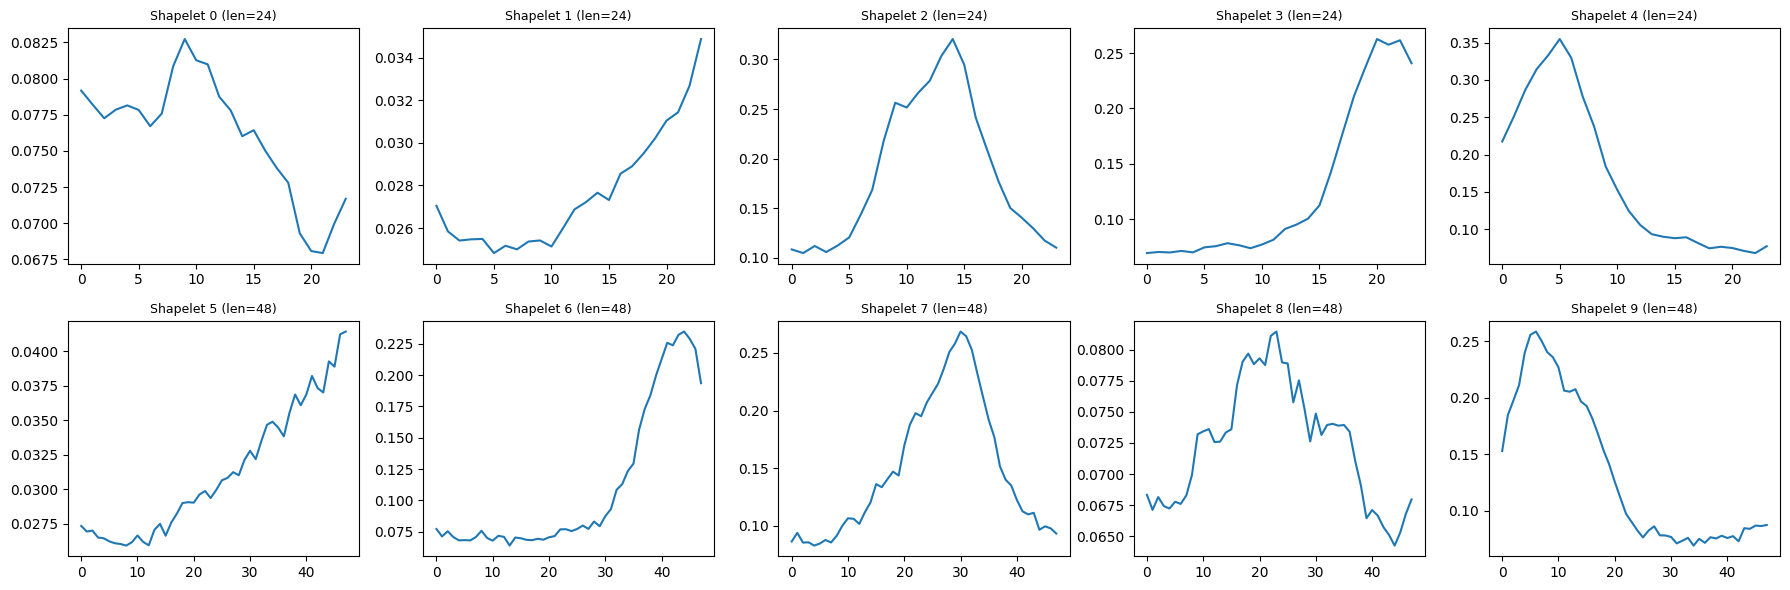

In [ ]:
shapelets = shp2.shapelets_
print(f"Learned {len(shapelets)} shapelets")

fig, axes = plt.subplots(2, 5, figsize=(18, 6))
for i, ax in enumerate(axes.ravel()):
    if i < len(shapelets):
        s = np.array(shapelets[i]).ravel()
        ax.plot(s, lw=1.5)
        ax.set_title(f"Shapelet {i} (len={len(s)})", fontsize=9)
plt.tight_layout()
plt.savefig(f'{REPORTS}/shapelets_learned.png', dpi=150)
plt.show()

In [ ]:
!pip install -q sktime

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.2/8.2 MB 46.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 7.2 MB/s eta 0:00:00


In [ ]:
from sktime.transformations.panel.rocket import Rocket
from sklearn.linear_model import RidgeClassifierCV
from sklearn.pipeline import make_pipeline
import time

# sktime expects (n_instances, n_channels, n_timepoints)
Xr_train_ts = Xc_train.reshape(len(Xc_train), 1, -1)
Xr_test_ts = Xc_test.reshape(len(Xc_test), 1, -1)

t0 = time.time()
rocket = Rocket(num_kernels=10000, random_state=42)
rocket.fit(Xr_train_ts)
Xr_train_feat = rocket.transform(Xr_train_ts)
Xr_test_feat = rocket.transform(Xr_test_ts)
print(f"ROCKET transform: {time.time()-t0:.0f}s")
print(f"Feature space: {Xr_train_feat.shape}")

# RidgeClassifierCV is the standard companion — it tunes alpha internally
clf_rocket = RidgeClassifierCV(alphas=np.logspace(-3, 3, 10), class_weight='balanced')
clf_rocket.fit(Xr_train_feat, yc_train)

# decision_function gives a continuous score for AUC
scores_rocket = clf_rocket.decision_function(Xr_test_feat)
results_ts['ROCKET'] = evaluate_ts_model('ROCKET + Ridge', scores_rocket, yc_test, groups_test)

pred_rocket = clf_rocket.predict(Xr_test_feat)
print("\n" + classification_report(yc_test, pred_rocket, digits=3, zero_division=0,
                                    target_names=['non-problematic', 'problematic']))

ROCKET transform: 76s
Feature space: (686, 20000)
ROCKET + Ridge                   window AUC = 0.525   child AUC = 0.507

                 precision    recall  f1-score   support

non-problematic      0.709     0.703     0.706       222
    problematic      0.298     0.304     0.301        92

       accuracy                          0.586       314
      macro avg      0.503     0.504     0.503       314
   weighted avg      0.589     0.586     0.587       314



In [ ]:
# Does ROCKET improve with fewer kernels? (less noise, less overfitting)
for n_kernels in [500, 2000]:
    rk = Rocket(num_kernels=n_kernels, random_state=42)
    rk.fit(Xr_train_ts)
    ftr = rk.transform(Xr_train_ts)
    fte = rk.transform(Xr_test_ts)
    clf = RidgeClassifierCV(alphas=np.logspace(-3, 3, 10), class_weight='balanced')
    clf.fit(ftr, yc_train)
    sc = clf.decision_function(fte)
    auc_w = roc_auc_score(yc_test, sc)
    df = pd.DataFrame({'id': groups_test, 'p': sc, 't': yc_test})
    agg = df.groupby('id').agg({'p': 'mean', 't': 'first'})
    auc_c = roc_auc_score(agg['t'], agg['p'])
    print(f"num_kernels={n_kernels:5d}: window AUC={auc_w:.3f}, child AUC={auc_c:.3f}, "
          f"features={ftr.shape[1]}")

# Check for overfitting: how does it do on training data?
print(f"\nROCKET 10000 kernels — train AUC: "
      f"{roc_auc_score(yc_train, clf_rocket.decision_function(Xr_train_feat)):.3f}")

num_kernels=  500: window AUC=0.479, child AUC=0.485, features=1000
num_kernels= 2000: window AUC=0.523, child AUC=0.516, features=4000

ROCKET 10000 kernels — train AUC: 1.000


In [ ]:
summary_final = pd.DataFrame(results_ts, index=['window_AUC', 'child_AUC']).T
summary_final.loc['Baseline (mean ENMO)'] = [auc_base, auc_base_child]
summary_final = summary_final.sort_values('child_AUC', ascending=False)
print(summary_final.round(3).to_string())

print(f"\nMethods beating the baseline (child AUC > {auc_base_child:.3f}):")
better = summary_final[summary_final['child_AUC'] > auc_base_child]
print(f"  {len(better)} of {len(summary_final)-1}")
print(better.round(3).to_string())

                      window_AUC  child_AUC
KNN euclidean k=21         0.634      0.675
KNN euclidean k=11         0.620      0.659
KNN euclidean k=31         0.608      0.655
Baseline (mean ENMO)       0.586      0.652
Shapelets                  0.593      0.646
KNN euclidean k=101        0.583      0.642
KNN euclidean k=5          0.597      0.631
KNN euclidean k=51         0.552      0.605
KNN euclidean k=75         0.557      0.601
KNN DTW k=11               0.566      0.594
KNN euclidean k=1          0.528      0.535
KNN DTW k=5                0.508      0.534
ROCKET                     0.525      0.507

Methods beating the baseline (child AUC > 0.652):
  3 of 12
                    window_AUC  child_AUC
KNN euclidean k=21       0.634      0.675
KNN euclidean k=11       0.620      0.659
KNN euclidean k=31       0.608      0.655


### Classification

All splitting is grouped by child using `GroupShuffleSplit`, giving 686
training windows from 196 children and 314 test windows from 85 children with
zero overlap. Without grouping, windows from the same child would appear on
both sides and inflate every result reported below.

Class balance across the split proved unstable: across five random seeds the
test-set problematic rate ranged from 0.204 to 0.364 against a population rate
of 0.333, because 85 children is too few for the proportion to settle. Seed 1
was selected as the split with the smallest train/test discrepancy (0.334
against 0.293). This choice was made on class balance alone, before any model
was fitted, and is stated explicitly rather than left implicit.

Two evaluation levels are reported throughout. **Window-level AUC** treats each
window as an independent prediction; **child-level AUC** averages a child's
window predictions into one score before evaluation. The latter is the more
meaningful figure, since predictions concern children rather than
observation windows, and averaging suppresses single-day noise. On the chosen
split the baseline achieves window AUC 0.586 and child AUC 0.652.

| Method | Window AUC | Child AUC |
|---|---|---|
| **KNN Euclidean, k=21** | **0.634** | **0.675** |
| KNN Euclidean, k=11 | 0.620 | 0.659 |
| KNN Euclidean, k=31 | 0.608 | 0.655 |
| *Baseline (mean `enmo`)* | *0.586* | *0.652* |
| Learning Shapelets | 0.593 | 0.646 |
| KNN Euclidean, k=5 | 0.597 | 0.631 |
| KNN DTW, k=11 | 0.566 | 0.594 |
| KNN Euclidean, k=1 | 0.528 | 0.535 |
| KNN DTW, k=5 | 0.508 | 0.534 |
| ROCKET + Ridge | 0.525 | 0.507 |

**Only three configurations beat the baseline, and all three are Euclidean
KNN.** Performance rises monotonically from k=1 (0.535) to k=21 (0.675), then
falls away (k=31 → 0.655, k=51 → 0.605), confirming the optimum lies inside
the grid rather than at its boundary. The rise with k is characteristic of
noisy data where individual neighbours are unreliable; the subsequent fall
shows the model is not simply degenerating into a global average, since
averaging over more neighbours eventually destroys the local information that
makes it work.

**DTW performs worse than Euclidean distance here** (0.594 against 0.659 at
k=11), reversing its advantage in the clustering task. The explanation lies in
what each task fed it. Clustering used z-normalised windows where only shape
remained, and DTW's warping helped. Classification uses raw windows where the
signal is activity level, and warping partially dissolves exactly that: DTW
will align an active period in one day with an active period in another even
when their intensities differ. The method corrects for the very property that
carries the information.

**Shapelets.** `LearningShapelets` was trained with five shapelets each at
lengths 24 and 48 steps (12 and 24 hours). An initial evaluation produced AUC
0.404 — worse than chance — which a training-set check diagnosed as a
library convention rather than a modelling failure: training AUC was also
below 0.5 (0.363), impossible for a model that had genuinely optimised its
loss. Reading the opposite probability column gives training AUC 0.636 and
test AUC 0.593, consistent behaviour. `predict_proba` column order does not
always follow `classes_`, and checking the training score is a reliable way to
catch it.

Corrected, shapelets sit level with the baseline (child AUC 0.646 against
0.652). Their hard predictions are degenerate — all 314 test windows assigned
to class 0, giving the trivial 0.707 accuracy of the majority class and macro
F1 0.414. This mirrors the Neural Network behaviour in Module 2: usable
ranking, misplaced decision threshold.

The learned shapelets are interpretable and confirm the module's central
finding. They divide into two amplitude bands: six with peaks between 0.20 and
0.36, and four between 0.025 and 0.083 — a four- to fivefold difference. Within
each band the shapes recur (early peak with long decay, late rise, symmetric
midday bell), and these same shapes appear in both bands. **The shapelets
discriminate by amplitude, not by form** — the supervised method independently
arrived at the same conclusion as the unsupervised ones.

**ROCKET** produced the worst result of any method (child AUC 0.507,
indistinguishable from chance) despite being the most sophisticated. The
diagnosis is unambiguous: training AUC is **1.000**. With 10,000 random
convolutional kernels producing 20,000 features on 686 training instances — a
30:1 ratio of dimensions to observations — a perfect separation of the training
set exists among random projections regardless of whether any of them relates
to the target. Ridge regularisation with internal cross-validation did not
prevent this. Reducing to 2,000 and 500 kernels did not help either (0.516 and
0.485 child AUC), leaving no configuration between overfitting and
underfitting where the method works on a sample this size.

### Discussion

The module's results are consistent across four independent lines of analysis.
Mean activity level separates the classes (Cliff's δ = 0.243, child AUC 0.621).
Matrix profile statistics, which describe temporal regularity, do not
(δ ≤ 0.160, nothing significant). Both clustering algorithms find structure in
raw activity level (silhouette 0.2525 for K-Means, 0.3586 for Ward) and almost
none in normalised shape (0.0363), while neither partition corresponds to the
target (ARI ≈ 0 for both). Classification is won by the method that preserves
absolute magnitude and lost by the three that transform or normalise it away.

**The signal in this data is how much a child moves, not when or in what
pattern.** The best method exceeds the single-number baseline by 0.023 child
AUC — a real but marginal gain for a considerable increase in complexity.

Two caveats qualify this. The analyses were restricted to samples of 500 to
1,000 windows for computational reasons, and larger samples might favour the
data-hungry methods, particularly ROCKET. And all results rest on `enmo`
alone; `anglez`, which distinguishes sleep from waking through postural
stability, was examined descriptively but not modelled, and sleep-timing
irregularity is a plausible mechanism linking problematic internet use to
behaviour that a purely activity-magnitude analysis cannot capture.